# 30 April 2026
- developing spectral model for CVs that is a one sided step function

In [2]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import numpy as np
from scipy import stats, interpolate
from matplotlib import pyplot as plt
import astropy.units as u
import astropy.constants as apyconst
import pandas as pd
import legwork as lw
#from sklearn.neighbors import KernelDensity
#from sklearn.model_selection import GridSearchCV
import copy
import corner
import pickle as pkl
import sys

%matplotlib inline
%config InlineBackend.figure_format='retina'

In [3]:
pops_CV_plot = pkl.load(open('../storage/run_outputs/prod_runs/dur12p6e7_inj_CVpop1_GBpop2_rec_n_mwspecfixedgal/plot_data.pickle', 'rb'))
pops_noCV_plot = pkl.load(open('../storage/run_outputs/prod_runs/dur12p6e7_inj_GBpop_rec_n_mwspecfixedgal/plot_data.pickle', 'rb'))

In [4]:
sys.path.append('/home/levis/lisa_projects/blip/blip/src/')
import submodel

In [5]:
def oneside_step_fn_4par_spectrum(fs, logAmin, logAmax, fmin, fmax):
    Sgw = np.where(fs < fmin, 10**logAmin, 10**logAmax) * np.where(fs < fmax, 1, 0)
    return Sgw

#submodel.compute_Omega0_from_Sgw(fs,Sgw)

In [6]:
fline = 3.5e-4 # LSS this is top of fmin prior and bottom of fmax prior
fminbot = 2e-4
fmaxtop = 6e-4

logAminbot = -48
logAmintop = -39 
logAmaxbot = -43
logAmaxtop = -35


tst = oneside_step_fn_4par_spectrum(pops_CV_plot['injspec_data']['data_psd']['psdfreqs'], -40.9, -40, 2.7e-4, 4.5e-4)
tstlow = oneside_step_fn_4par_spectrum(pops_CV_plot['injspec_data']['data_psd']['psdfreqs'], logAminbot, logAmaxbot, fminbot, fline)
tsthigh = oneside_step_fn_4par_spectrum(pops_CV_plot['injspec_data']['data_psd']['psdfreqs'], logAmintop, logAmaxtop, fline, fmaxtop)

In [7]:
print(np.log10(fline))
print(np.log10(fminbot))
print(np.log10(fmaxtop))

-3.4559319556497243
-3.6989700043360187
-3.2218487496163566


[]

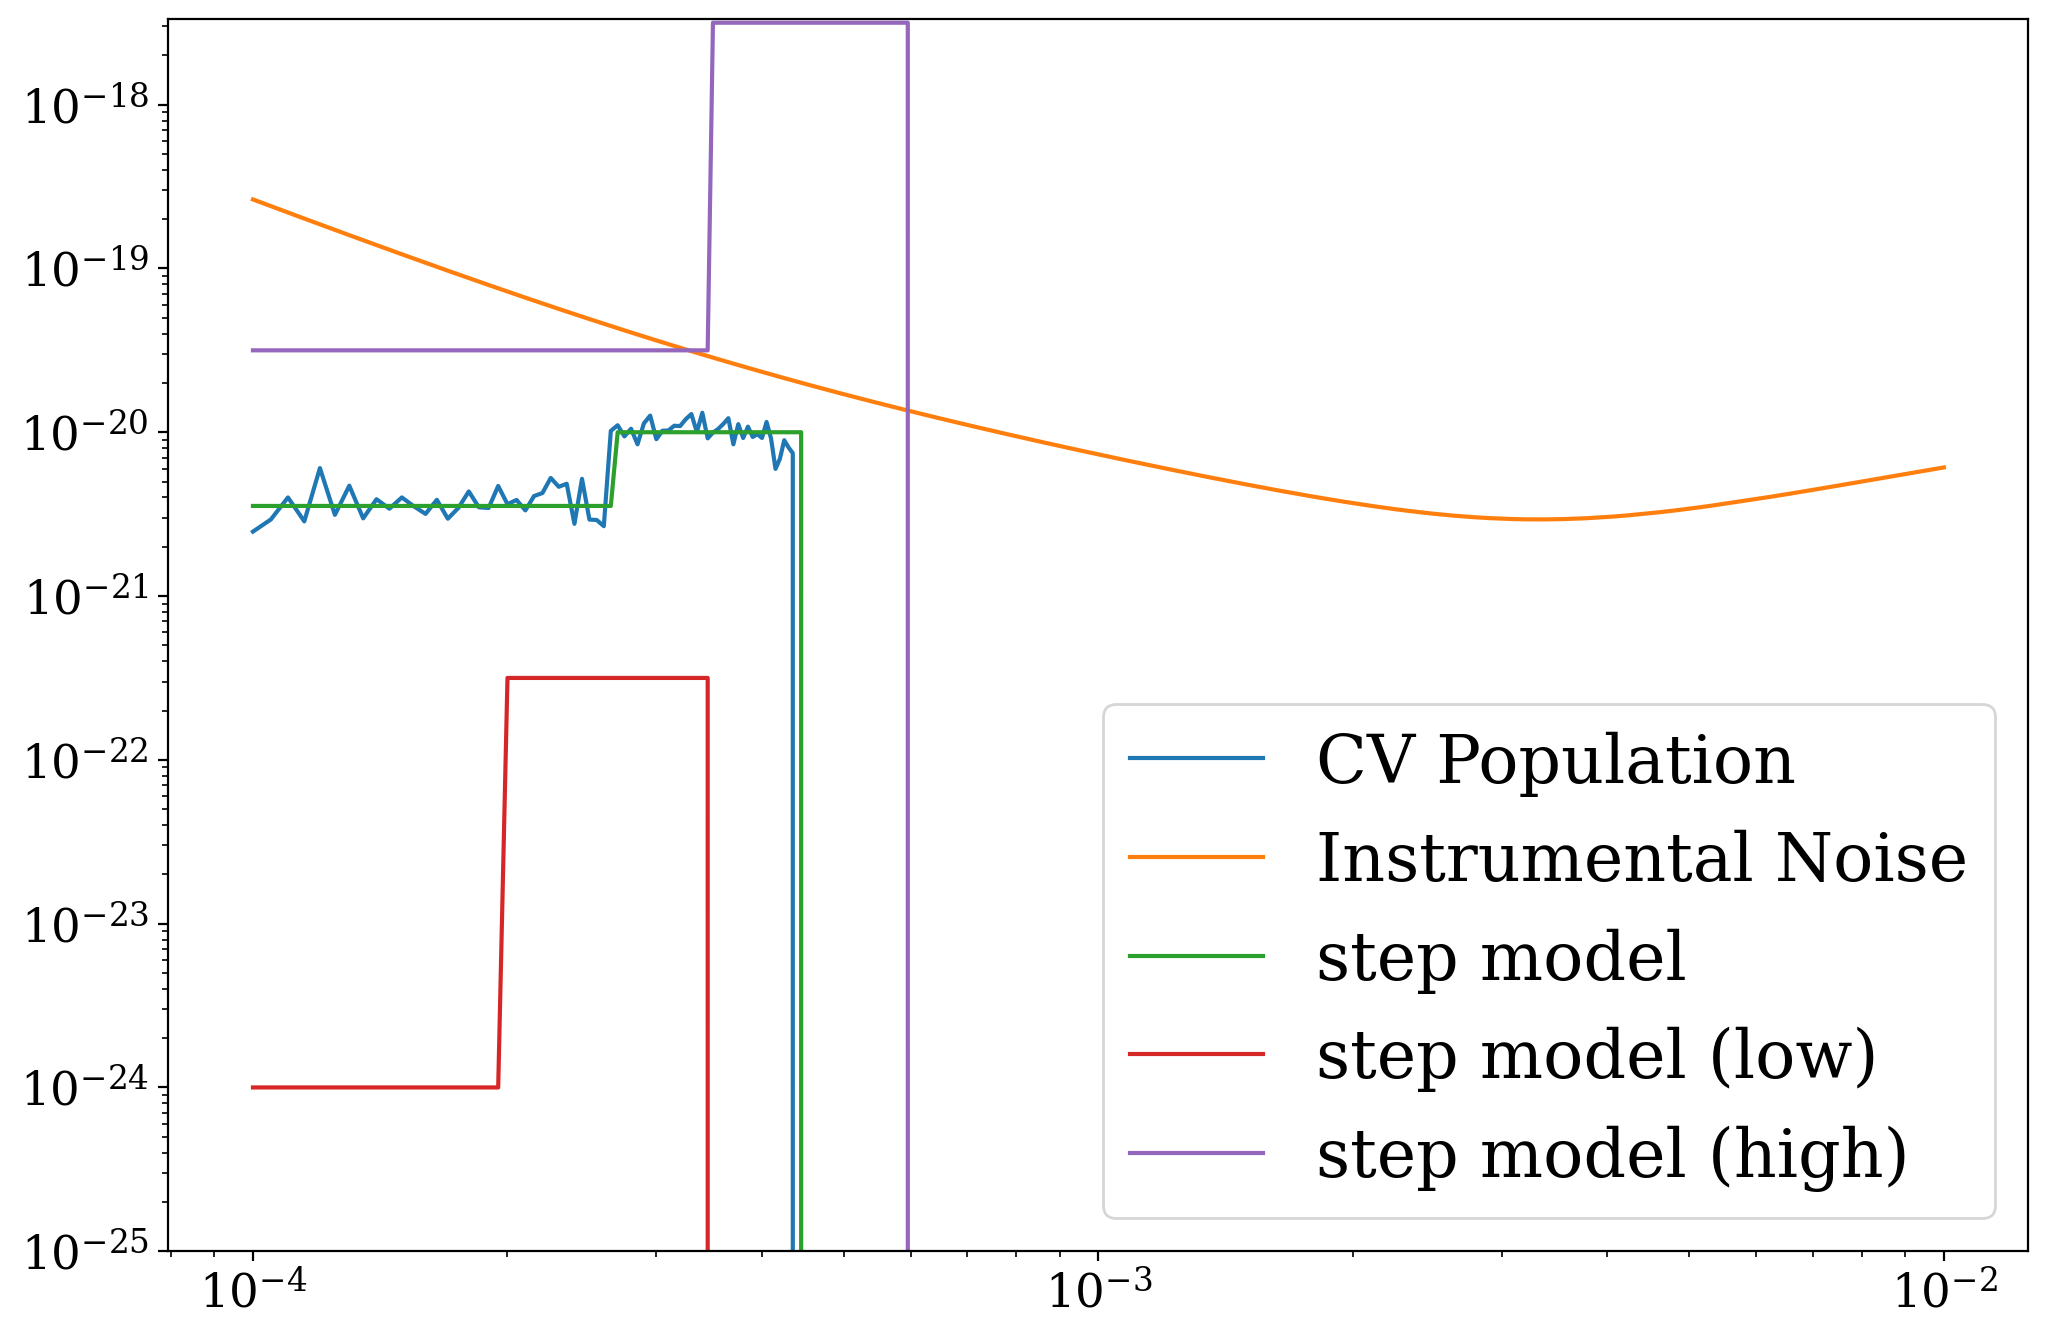

In [8]:
fig, ax = plt.subplots()


ax.plot(pops_CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(pops_CV_plot['injspec_data']['population-1']['S1_gw']), label='CV Population')
ax.plot(pops_CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(pops_CV_plot['injspec_data']['noise_spectra']['noise1']), label='Instrumental Noise')
ax.plot(pops_CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(tst), label='step model')
ax.plot(pops_CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(tstlow), label='step model (low)')
ax.plot(pops_CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(tsthigh), label='step model (high)')
ax.set_ylim(1e-25, None)
#ax.set_xlim(1e-5, None)
plt.legend()
plt.loglog()